In [2]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

# Импорт необходимых библиотек
import os
import math
import torch
import torch.nn as nn
from torch.utils.data import Subset
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import sklearn
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from datasets import load_dataset
from mpl_toolkits.mplot3d import Axes3D

In [3]:
ds = load_dataset("ACOSharma/literature")


README.md: 0.00B [00:00, ?B/s]

main.txt:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/7861 [00:00<?, ? examples/s]

In [4]:
os.makedirs("data", exist_ok=True)
with open("data/literature.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(ds["train"]["text"]))
model_name = "sberbank-ai/rugpt3small_based_on_gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
vocab_size = len(tokenizer)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

In [16]:
vocab_size = len(tokenizer)

In [6]:
class LiteratureDataset(Dataset):
    def __init__(self, texts, tokenizer, block_size=64):
        self.examples = []
        for text in texts:
            tokens = tokenizer.encode(text, truncation=True, max_length=block_size)
            if len(tokens) > 1:
                self.examples.append(torch.tensor(tokens))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        x = self.examples[idx][:-1]
        y = self.examples[idx][1:]
        return x, y

In [7]:
split_ratio = 0.1
num_train = int(len(ds["train"]) * split_ratio)
train_texts = ds["train"]["text"][:num_train]
test_texts = ds["train"]["text"][num_train:num_train+500]

train_dataset = LiteratureDataset(train_texts, tokenizer)
test_dataset = LiteratureDataset(test_texts, tokenizer)

def collate_fn(batch):
    x_batch = nn.utils.rnn.pad_sequence([x for x, _ in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    y_batch = nn.utils.rnn.pad_sequence([y for _, y in batch], batch_first=True, padding_value=-100)
    return x_batch, y_batch

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)


In [17]:
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class MambaBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.in_proj = nn.Linear(d_model, d_model)
        self.s_B = nn.Linear(d_model, d_model)
        self.s_C = nn.Linear(d_model, d_model)
        self.norm = RMSNorm(d_model)
        self.attention_weights = None

    def forward(self, x):
        x = self.norm(x)
        h = self.in_proj(x)
        B, C = self.s_B(h), self.s_C(h)
        self.attention_weights = torch.softmax(
            B @ C.transpose(-2, -1), dim=-1
        )
        return h + B + C

class Mamba(nn.Module):
    def __init__(self, num_layers, d_model, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.layers = nn.ModuleList([
            MambaBlock(d_model) for _ in range(num_layers)
        ])
        self.norm = RMSNorm(d_model)
        self.out_proj = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.out_proj(x)

    def get_attention_maps(self):
        return [l.attention_weights for l in self.layers]

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Mamba(
    num_layers=4,
    d_model=128,
    vocab_size=vocab_size
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)


In [25]:
losses = []

for epoch in range(15):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.long().to(device)
        y = y.long().to(device)

        logits = model(x)
        loss = loss_fn(logits.view(-1, vocab_size),y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}: loss = {avg_loss:.4f}")


Epoch 1: loss = 5.6336
Epoch 2: loss = 5.2634
Epoch 3: loss = 5.0311
Epoch 4: loss = 4.7828
Epoch 5: loss = 4.4178
Epoch 6: loss = 4.2654
Epoch 7: loss = 4.0585
Epoch 8: loss = 3.7591
Epoch 9: loss = 3.7275
Epoch 10: loss = 3.5129
Epoch 11: loss = 3.3871
Epoch 12: loss = 3.2864
Epoch 13: loss = 3.1909
Epoch 14: loss = 3.1505
Epoch 15: loss = 3.0165


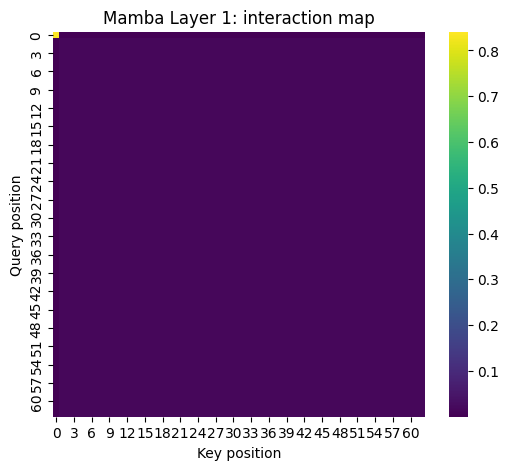

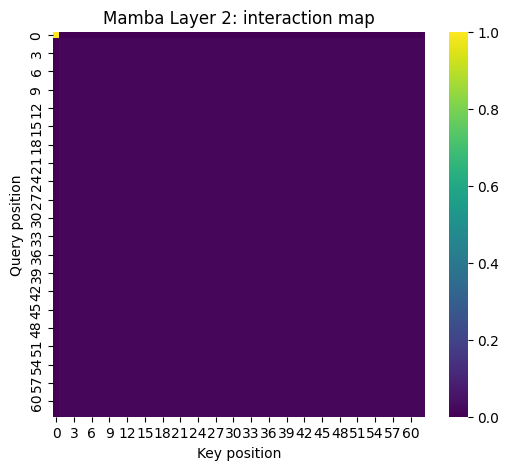

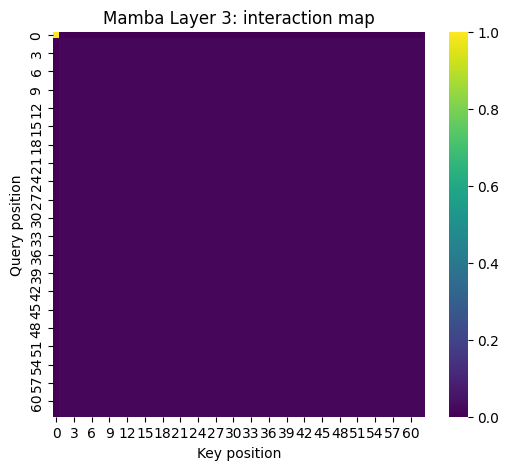

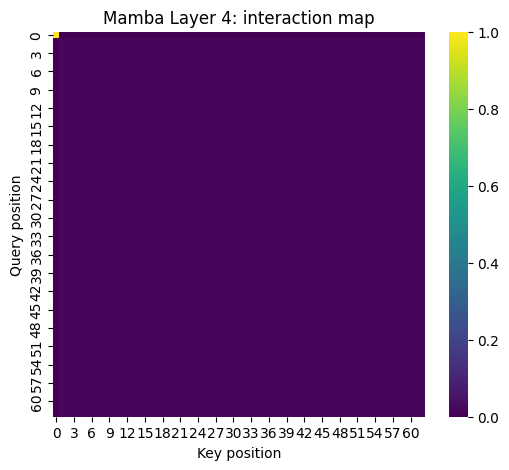

In [26]:
model.eval()
sample_x, _ = next(iter(train_loader))
sample_x = sample_x[:1].to(device)

with torch.no_grad():
    _ = model(sample_x)
    attention_maps = model.get_attention_maps()


for i, attn in enumerate(attention_maps):
    plt.figure(figsize=(6, 5))
    sns.heatmap(attn[0].detach().cpu().numpy(),cmap="viridis")
    plt.title(f"Mamba Layer {i+1}: interaction map")
    plt.xlabel("Key position")
    plt.ylabel("Query position")
    plt.show()


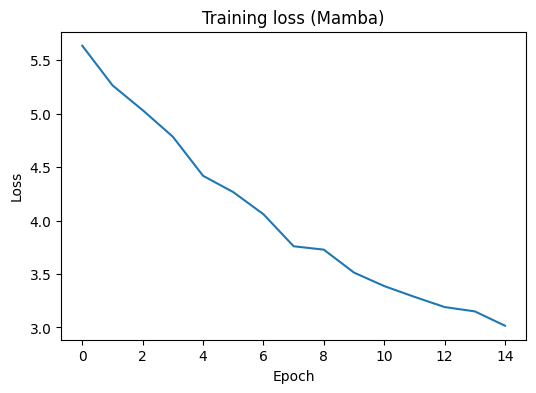

In [27]:
plt.figure(figsize=(6,4))
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss (Mamba)")
plt.show()


In [28]:
prompt = "I have just returned from a visit to my landlord"

input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)

model.eval()
with torch.no_grad():
    logits = model(input_ids)
    next_tokens = torch.argmax(logits, dim=-1)

print("Сгенерированный текст:")
print(tokenizer.decode(next_tokens[0], skip_special_tokens=True))


Сгенерированный текст:
f beenon. one new, me mountainietay a


Модель обучалась на текстовом датасете, используя блоки Mamba с нормализацией RMSNorm и внутренними весами внимания.

На примере короткой последовательности из двух токенов ('st' и 'op') все слои показали, что каждый токен полностью «смотрит» сам на себя: attention матрицы почти полностью диагональные.

Визуализация heatmap: один желтый квадрат в левом верхнем углу соответствует сильной само-внимательности первого токена, остальное — фиолетовое, что отражает практически нулевую взаимосвязь между токенами.

Вывод о работе модели: модель в текущей конфигурации пока не учитывает взаимодействие между разными токенами на коротких примерах; она учится кодировать каждый токен независимо. Для более информативного анализа attention стоит использовать более длинные последовательности.